# Projet : Filtrage de Kalman
_Auteur : ClapTrap – Objectif : Réaliser un filtre qui retrouve biais et angle d'un IMU en déplacement 1D(rot) pour lequel on dispose des mesures d'accélération et de gyroscopie_
_Date : 2026-04-03_
---


## 2. Installation et import des bibliothèques

Regrouper ici toutes les installations `pip` propres à Colab et tous les imports.

In [25]:
import math
import numpy as np
import matplotlib.pyplot as plt

# Optionnel : configuration d'affichage
np.set_printoptions(precision=4, suppress=True)

from filterpy.kalman import KalmanFilter

## 3. Définition des paramètres globaux

Centraliser ici les constantes, chemins, et paramètres configurables.

In [26]:
# Paramètres globaux
# InputDataPath = BaseWorkingPath + "/input"
# OutputDataPath = BaseWorkingPath + "/output"

# DefaultSampleSize = 100  # nombre d'instants de mesure  # <<<
TotalTime = 100
DefaultSampleSize = 1000  # nombre d'instants de mesure  # <<<

RandomSeed = 123
np.random.seed(RandomSeed)

# Paramètres du modèle de mouvement  # <<<
TimeStep = float(TotalTime / DefaultSampleSize)  # période d'échantillonage (s)  # <<<

TrueInitialAlpha = 0.0  # angle initial vrai (°)        # <<<
TrueInitialAlphadot = 0.0  # vitesse angulaire initiale vraie (°/s)        # <<<
TrueInitialBias = 100.0  # biais de vitesse angulaire vrai (°/s)             # <<<
MeasurementAlphaNoiseStd = 5.0  # => R écart-type du bruit de mesure sur alpha  # <<<
MeasurementAlphadotNoiseStd = 5.0  # => R écart-type du bruit de mesure sur alphadot   # <<<
ProcessAlphaNoiseStd = 10  # => Q bruit de processus (sur alpha)  # <<<
ProcessAlphadotNoiseStd = 10  # => Q bruit de processus (sur alphadot)  # <<<
ProcessBiasNoiseStd = 10  # => Q bruit de processus (sur bias)  # <<<

## 4. Définition des fonctions principales

Regrouper ici les fonctions réutilisables pour le traitement.

In [27]:
def GenerateTrueValuesAndMeasurements(sampleSize: int):
    """
    Generate values with piecewise constant acceleration
    and noisy position measurements.
    """
    print(f"TimeStep : {TimeStep}")

    timeArray = np.arange(sampleSize, dtype=float) * TimeStep
    print(f"timeArray : {timeArray}, len : {len(timeArray)}")
    trueAlphaArray = np.zeros(sampleSize, dtype=float)
    trueAlphadotArray = np.zeros(sampleSize, dtype=float)

    currentAlpha = TrueInitialAlpha
    currentAlphadot = TrueInitialAlphadot

    for indexTime in range(sampleSize):
        currentTime = timeArray[indexTime]

        # Acceleration profile (piecewise)
        if currentTime < 20.0:
            currentAlphadotdot = 0.0
        elif currentTime < 40.0:
            currentAlphadotdot = 0.5
        elif currentTime < 60.0:
            currentAlphadotdot = -0.3
        else:
            currentAlphadotdot = 0.0

        currentAlphadot = currentAlphadot + currentAlphadotdot * TimeStep
        currentAlpha = currentAlpha + currentAlphadot * TimeStep

        trueAlphaArray[indexTime] = currentAlpha
        trueAlphadotArray[indexTime] = currentAlphadot

    print(f"trueAlphaArray : {trueAlphaArray}, len : {len(trueAlphaArray)}")
    print(f"trueAlphadotArray : {trueAlphadotArray}, len : {len(trueAlphadotArray)}")

    measurementNoiseArray = np.random.normal(
        loc=0.0,
        scale=MeasurementAlphaNoiseStd,
        size=sampleSize
    )
    measuredAlphaArray = trueAlphaArray + measurementNoiseArray

    measurementNoiseArray = np.random.normal(
        loc=0.0,
        scale=MeasurementAlphadotNoiseStd,
        size=sampleSize
    )
    measuredAlphadotArray = trueAlphadotArray + TrueInitialBias + measurementNoiseArray

    return timeArray, trueAlphaArray, trueAlphadotArray, measuredAlphaArray, measuredAlphadotArray

In [28]:
def CreateKalmanFilter():
    """

    """
    kalmanFilter = KalmanFilter(dim_x=3, dim_z=2)

    kalmanFilter.x = np.array([
        [TrueInitialAlpha],
        [TrueInitialAlphadot],
        [TrueInitialBias]
    ])

    kalmanFilter.F = np.array([
        [1.0, TimeStep, 0.0],
        [0.0, 1.0, 0.0],
        [0.0, 0.0, 1.0]
    ])

    kalmanFilter.H = np.array([
        [1.0, 0.0, 0.0],
        [0.0, 1.0, 1.0]
    ])

    kalmanFilter.P = np.array([
        [500.0, 0.0, 0.0],
        [0.0, 500.0, 0.0],
        [0.0, 0.0, 500.0]
    ])

    kalmanFilter.R = np.diag([
        MeasurementAlphaNoiseStd ** 2,
        MeasurementAlphadotNoiseStd ** 2
    ])

    # q = ProcessNoiseStdAcceleration ** 2
    # dt = TimeStep
    # kalmanFilter.Q = np.array([
    #     [0.25 * dt**4 * q, 0.5 * dt**3 * q],
    #     [0.5 * dt**3 * q,  dt**2 * q]
    # ])

    kalmanFilter.Q = np.diag([
        ProcessAlphaNoiseStd ** 2,
        ProcessAlphadotNoiseStd ** 2,
        ProcessBiasNoiseStd ** 2
    ])

    return kalmanFilter

In [29]:
def ApplyKalmanFilterOnMeasurements(kalmanFilter: KalmanFilter,
                                    measuredAlphaArray: np.ndarray,
                                    measuredAlphadotArray: np.ndarray,
                                    ):
    """
    Apply the Kalman filter step-by-step on noisy measurements
    and return estimated position and velocity arrays.
    """
    estimatedAlphaList = []
    estimatedAlphadotList = []
    estimatedBiasList = []

    for measuredAlpha, measuredAlphadot in zip(measuredAlphaArray, measuredAlphadotArray):
        kalmanFilter.predict()
        kalmanFilter.update(np.array([[measuredAlpha, measuredAlphadot]]))

        estimatedAlphaList.append(float(kalmanFilter.x[0, 0]))
        estimatedAlphadotList.append(float(kalmanFilter.x[1, 0]))
        estimatedBiasList.append(float(kalmanFilter.x[2, 0]))

    estimatedAlphaArray = np.array(estimatedAlphaList)
    estimatedAlphadotArray = np.array(estimatedAlphadotList)
    estimatedBiasArray = np.array(estimatedBiasList)

    return estimatedAlphaArray, estimatedAlphadotArray, estimatedBiasArray

## 5. Exécution principale

Utiliser les fonctions définies pour produire les résultats.

In [30]:
# Génération du comportement vrai et des mesures bruitées
(TimeArray,
 TrueAlphaArray,
 TrueAlphadotArray,
 MeasuredAlphaArray,
 MeasuredAlphadotArray) = GenerateTrueValuesAndMeasurements(DefaultSampleSize)

TimeStep : 0.1
timeArray : [ 0.   0.1  0.2  0.3  0.4  0.5  0.6  0.7  0.8  0.9  1.   1.1  1.2  1.3
  1.4  1.5  1.6  1.7  1.8  1.9  2.   2.1  2.2  2.3  2.4  2.5  2.6  2.7
  2.8  2.9  3.   3.1  3.2  3.3  3.4  3.5  3.6  3.7  3.8  3.9  4.   4.1
  4.2  4.3  4.4  4.5  4.6  4.7  4.8  4.9  5.   5.1  5.2  5.3  5.4  5.5
  5.6  5.7  5.8  5.9  6.   6.1  6.2  6.3  6.4  6.5  6.6  6.7  6.8  6.9
  7.   7.1  7.2  7.3  7.4  7.5  7.6  7.7  7.8  7.9  8.   8.1  8.2  8.3
  8.4  8.5  8.6  8.7  8.8  8.9  9.   9.1  9.2  9.3  9.4  9.5  9.6  9.7
  9.8  9.9 10.  10.1 10.2 10.3 10.4 10.5 10.6 10.7 10.8 10.9 11.  11.1
 11.2 11.3 11.4 11.5 11.6 11.7 11.8 11.9 12.  12.1 12.2 12.3 12.4 12.5
 12.6 12.7 12.8 12.9 13.  13.1 13.2 13.3 13.4 13.5 13.6 13.7 13.8 13.9
 14.  14.1 14.2 14.3 14.4 14.5 14.6 14.7 14.8 14.9 15.  15.1 15.2 15.3
 15.4 15.5 15.6 15.7 15.8 15.9 16.  16.1 16.2 16.3 16.4 16.5 16.6 16.7
 16.8 16.9 17.  17.1 17.2 17.3 17.4 17.5 17.6 17.7 17.8 17.9 18.  18.1
 18.2 18.3 18.4 18.5 18.6 18.7 18.8 18.9 19.  19.1

In [31]:
# Création et configuration du filtre de Kalman
KF = CreateKalmanFilter()

In [32]:
# Génération du comportement vrai et des mesures bruitées
# Application du filtre sur toutes les mesures
(EstimatedAlphaArray,
 EstimatedAlphadotArray,
 EstimatedBiasArray) = ApplyKalmanFilterOnMeasurements(
    KF,
    MeasuredAlphaArray,
    MeasuredAlphadotArray
)

print("FirstTrueAlpha     =", TrueAlphaArray[0])
print("FirstMeasuredAlpha =", MeasuredAlphaArray[0])
print("FirstEstimatedAlpha =", EstimatedAlphaArray[0])
print("FirstTrueAlphadot     =", TrueAlphadotArray[0])
print("FirstEstimatedAlphadot =", EstimatedAlphadotArray[0])

FirstTrueAlpha     = 0.0
FirstMeasuredAlpha = -5.428153016502806
FirstEstimatedAlpha = -5.218134148162748
FirstTrueAlphadot     = 0.0
FirstEstimatedAlphadot = -2.048168148680347


## 6. Visualisation des résultats

Tracer les données ou les résultats principaux.

In [37]:
print(f"MeasurementAlphaNoiseStd = {MeasurementAlphaNoiseStd}")
print(f"MeasurementAlphadotNoiseStd = {MeasurementAlphadotNoiseStd}")
print(f"ProcessAlphaNoiseStd = {ProcessAlphaNoiseStd}")
print(f"ProcessAlphadotNoiseStd = {ProcessAlphadotNoiseStd}")
print(f"ProcessBiasNoiseStd = {ProcessBiasNoiseStd}")

MeasurementAlphaNoiseStd = 5.0
MeasurementAlphadotNoiseStd = 5.0
ProcessAlphaNoiseStd = 10
ProcessAlphadotNoiseStd = 10
ProcessBiasNoiseStd = 10


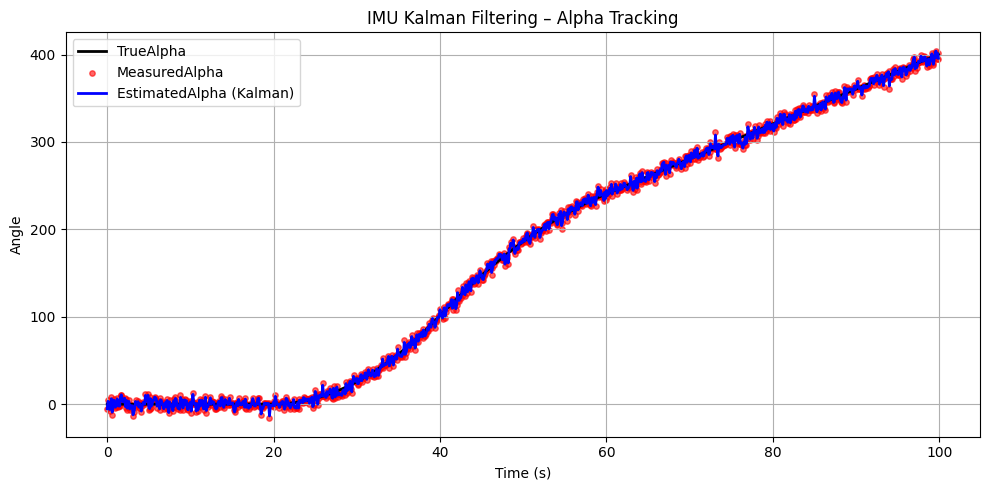

In [34]:
plt.figure(figsize=(10, 5))

plt.plot(TimeArray,
         TrueAlphaArray,
         label="TrueAlpha",
         color="black",
         linewidth=2)

plt.scatter(TimeArray,
            MeasuredAlphaArray,
            label="MeasuredAlpha",
            color="red",
            s=15,
            alpha=0.6)

plt.plot(TimeArray,
         EstimatedAlphaArray,
         label="EstimatedAlpha (Kalman)",
         color="blue",
         linewidth=2)

plt.title("IMU Kalman Filtering – Alpha Tracking")
plt.xlabel("Time (s)")
plt.ylabel("Angle")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

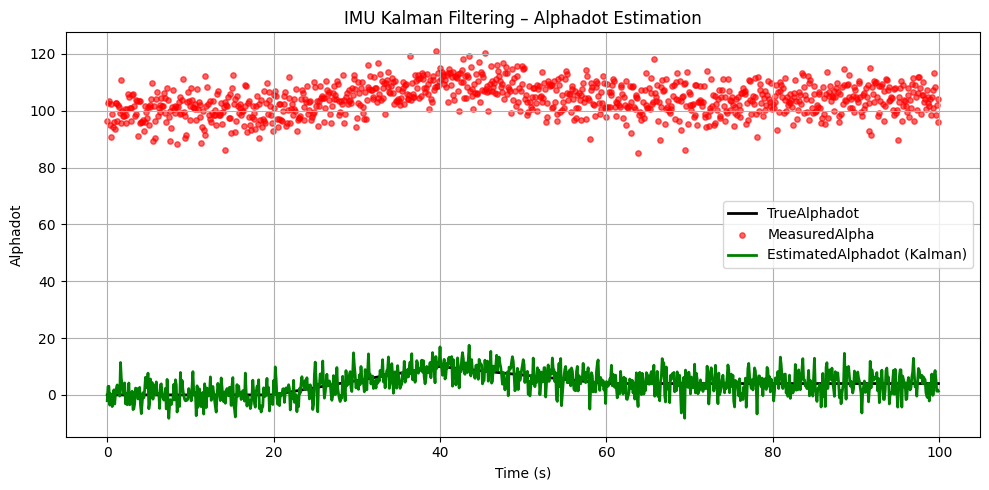

In [35]:
plt.figure(figsize=(10, 5))  # <<<

plt.plot(TimeArray,
         TrueAlphadotArray,
         label="TrueAlphadot",
         color="black",
         linewidth=2)  # <<<

plt.scatter(TimeArray,
            MeasuredAlphadotArray,
            label="MeasuredAlpha",
            color="red",
            s=15,
            alpha=0.6)

plt.plot(TimeArray,
         EstimatedAlphadotArray,
         label="EstimatedAlphadot (Kalman)",
         color="green",
         linewidth=2)  # <<<

plt.title("IMU Kalman Filtering – Alphadot Estimation")  # <<<
plt.xlabel("Time (s)")
plt.ylabel("Alphadot")  # <<<
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

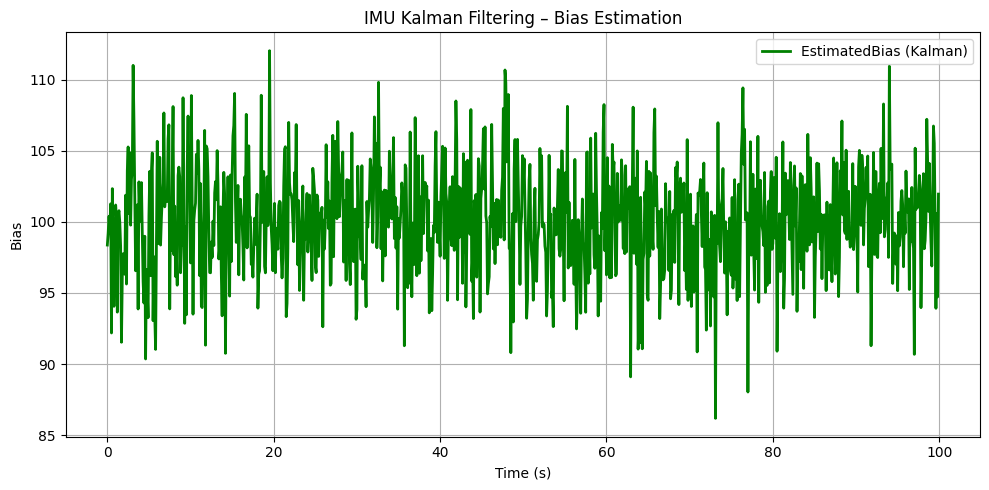

In [36]:
plt.figure(figsize=(10, 5))  # <<<

plt.plot(TimeArray,
         EstimatedBiasArray,
         label="EstimatedBias (Kalman)",
         color="green",
         linewidth=2)  # <<<

plt.title("IMU Kalman Filtering – Bias Estimation")  # <<<
plt.xlabel("Time (s)")
plt.ylabel("Bias")  # <<<
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()